Title: LEE_Results_Analysis.ipynb

Purpose: Look at the found LEE Events

Author: Onno Nennecke on 16.07.2025 Modified: 11.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- Plots: LEE_Event_yearly_distr, LEE_durations_comparison
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import dask.array as da

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

import scipy.ndimage as ndimage
from scipy.stats import norm
from scipy import stats
import os
import glob

from datetime import datetime

### Read LEE data

In [2]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


---

### General Count

In [3]:
print(sum(LEE_dat['duration']))
print(sum(LEE_7['duration']))
print(sum(LEE_14['duration']))
print(sum(LEE_vl['duration']))

print(sum(LEE_dat['duration'])/ sum(LEE_7['duration']))

18605
8008
3640
18605
2.323301698301698


In [4]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.217750,1433.217750,0.0,1433.217750,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.194500,1446.194500,0.0,1446.194500,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.966000,1409.966000,0.0,1409.966000,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,18604,SMARD,SMARD_hist,2024,345


---

In [5]:
# Pure ERA5 data
LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]

In [6]:
max(LEE_dat_ERA5['RL_cumulative'])
LEE_dat_ERA5[173:174]['RL_cumulative']
# LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')][173:180]
LEE_dat_ERA5[173:174]['RL_cumulative'].values[0]

np.float64(1427.7965993926362)

In [7]:
LEE_7[(LEE_7['ESM'] == 'ERA5_week')]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
550,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1497.249011,1449.366519,46.744941,10145.565631,551,ERA5_week,ERA5_hist_week,2015,19
551,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1502.737606,1456.367093,32.641307,10194.569654,552,ERA5_week,ERA5_hist_week,2016,15
552,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000003,712,718,715,7,1458.652965,1415.033120,53.764337,9905.231838,553,ERA5_week,ERA5_hist_week,2016,348
553,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1541.727728,1478.688488,49.626313,10350.819414,554,ERA5_week,ERA5_hist_week,2017,19
554,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1542.347000,1450.622709,86.209183,10154.358961,555,ERA5_week,ERA5_hist_week,2019,19
555,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1470.258197,1424.666513,40.762916,9972.665588,556,ERA5_week,ERA5_hist_week,2020,330
556,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1554.145256,1492.080803,26.066980,10444.565622,557,ERA5_week,ERA5_hist_week,2022,344
557,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1502.508759,1411.341731,74.062268,9879.392118,558,ERA5_week,ERA5_hist_week,2023,20
558,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000006,2941,2947,2947,7,1460.861030,1418.133334,51.195259,9926.933336,559,ERA5_week,ERA5_hist_week,2023,22
559,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1540.015423,1450.126204,77.766638,10150.883425,560,ERA5_week,ERA5_hist_week,2023,331


In [8]:
LEE_7_ERA5[3:4]['RL_cumulative'].values[0]

np.float64(10350.819413554604)

### Cumulative RL Distribution

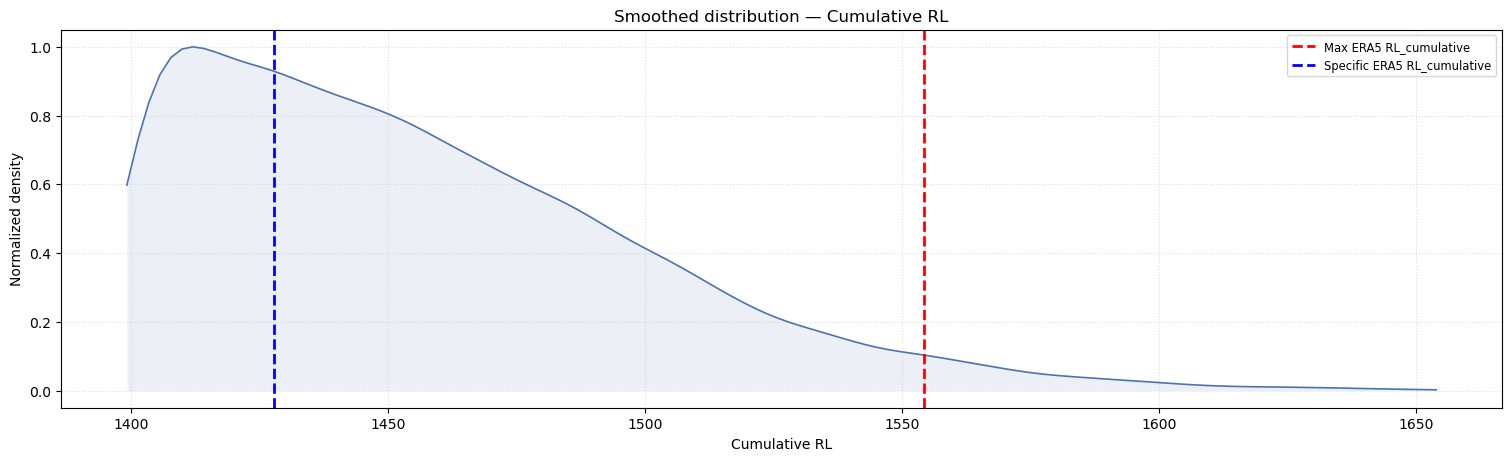

In [9]:
# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size
color_all = '#4c72b0'
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  # 3 subplots in a row

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_dat['RL_cumulative'].values  # all data array

# common bin edges spanning min..max across all 3 sets so curves align
edges = np.linspace(a.min(), a.max(), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

# histogram counts (density=False -> raw counts) computed on the same edges
ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all

# normalize so the largest peak among the three equals 1 (same as your original)
peak = max(sa.max(), 1e-12)  # avoid division by zero
sa /= peak  # normalized all

# plotting curves + fills
ax.plot(centers, sa, lw=lw, color=color_all)  # all curve
ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

# Add a vertical marker line at the most common RL_cumulative value
ax.axvline(max(LEE_dat_ERA5['RL_cumulative']), color='red', linestyle='--', linewidth=2, label='Max ERA5 RL_cumulative')
ax.axvline(LEE_dat_ERA5[173:174]['RL_cumulative'].values[0], color='blue', linestyle='--', linewidth=2, label='Specific ERA5 RL_cumulative')

# labels and styling
ax.set_title('Smoothed distribution — Cumulative RL')  # subplot title
ax.set_xlabel('Cumulative RL')  # x label
ax.set_ylabel('Normalized density')  # y label
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(fontsize='small')  # legend

plt.show()  # display


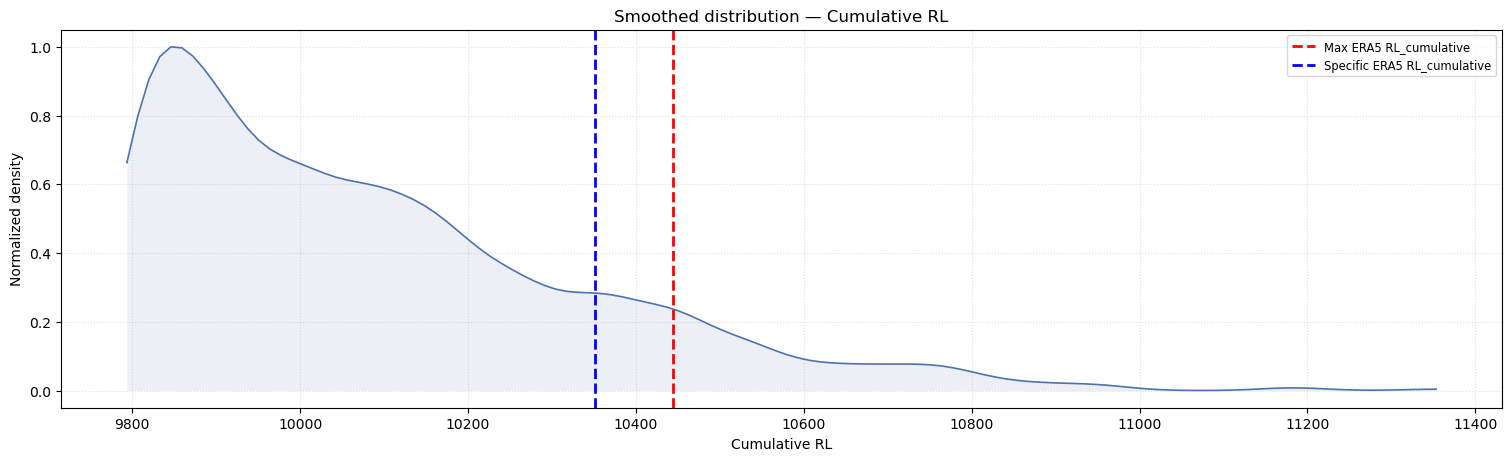

In [10]:
# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size
color_all = '#4c72b0'
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  # 3 subplots in a row

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_7['RL_cumulative'].values  # all data array

# common bin edges spanning min..max across all 3 sets so curves align
edges = np.linspace(a.min(), a.max(), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

# histogram counts (density=False -> raw counts) computed on the same edges
ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all

# normalize so the largest peak among the three equals 1 (same as your original)
peak = max(sa.max(), 1e-12)  # avoid division by zero
sa /= peak  # normalized all

# plotting curves + fills
ax.plot(centers, sa, lw=lw, color=color_all)  # all curve
ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

# Add a vertical marker line at the most common RL_cumulative value
ax.axvline(max(LEE_7_ERA5['RL_cumulative']), color='red', linestyle='--', linewidth=2, label='Max ERA5 RL_cumulative')
ax.axvline(LEE_7_ERA5[3:4]['RL_cumulative'].values[0], color='blue', linestyle='--', linewidth=2, label='Specific ERA5 RL_cumulative')

# labels and styling
ax.set_title('Smoothed distribution — Cumulative RL')  # subplot title
ax.set_xlabel('Cumulative RL')  # x label
ax.set_ylabel('Normalized density')  # y label
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(fontsize='small')  # legend

plt.show()  # display


### Check doy distribution

In [11]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]


In [12]:
# # Function to create a list of dates from start_date to end_date from the LEE data
# def create_date_list(LEE_data):
#     """
#     Generates a list of date strings from the start_date to end_date
#     for each event in the LEE_data DataFrame.

#     Parameters:
#         LEE_data (pd.DataFrame): A DataFrame containing 'date_start' and 'date_end' columns.

#     Returns:
#         list: A list of date strings in 'YYYY-MM-DD' format.
#     """
#     date_list = []
#     for start, end in zip(LEE_data['date_start'], LEE_data['date_end']):
#         dates = pd.date_range(start=start, end=end, freq='D')
#         date_list.extend(d.strftime('%Y-%m-%d') for d in dates)
#     return date_list


In [13]:
# Precompute cumulative days at month start in a non-leap year
_NONLEAP_CUMDAYS = {1:   0, 2:  31, 3:  59, 4:  90, 5: 120, 6: 151, 7: 181, 8: 212, 9: 243, 10: 273, 11: 304, 12: 334}

def _md_to_doy(month: int, day: int) -> int:
    """
    Convert month/day in a non-leap year to day-of-year (1-365).
    """
    return _NONLEAP_CUMDAYS[month] + day

def create_doy_list(LEE_data: pd.DataFrame) -> list[int]:
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute their non-leap DOYs (1-365), and then return all DOYs in that interval
    (inclusive), wrapping across year-end if start > end.

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[int]: flat list of DOYs (1-365) covering each event.
    """
    doy_list: list[int] = []

    for start_str, end_str in zip(LEE_data['date_start'], LEE_data['date_end']):
        # parse out month/day
        ms, ds = datetime.strptime(start_str, "%Y-%m-%d").month, datetime.strptime(start_str, "%Y-%m-%d").day
        me, de = datetime.strptime(end_str,   "%Y-%m-%d").month, datetime.strptime(end_str,   "%Y-%m-%d").day

        start_doy = _md_to_doy(ms, ds)
        end_doy   = _md_to_doy(me, de)

        if start_doy <= end_doy:
            interval = range(start_doy, end_doy + 1)
        else:
            # wrap across year boundary
            interval = list(range(start_doy, 366)) + list(range(1, end_doy + 1))

        doy_list.extend(interval)

    return doy_list


In [14]:
LEE_dat_dl = create_doy_list(LEE_dat)
LEE_vl_dl = create_doy_list(LEE_vl)
LEE_7_dl = create_doy_list(LEE_7)
LEE_14_dl = create_doy_list(LEE_14)

### Check the LEE days for each month

In [49]:
# Precomputed non-leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

def plot_oct_apr_centered(doy, title, ax=None, left_axis=True):
    """
    Plots a daily-DOY histogram for Oct1–Apr30, with winter (Nov–Apr)
    centered in the middle of the x-axis.

    Args:
        doy (iterable of int): List/array/Series of day-of-year values (1–365).
        ax (matplotlib.axes.Axes): Axes to plot into. If None, uses current axes.
        left_axis (bool): If True, show y-axis label/ticks; otherwise hide them.
    """
    if ax is None:
        ax = plt.gca()

    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    # 5) Plot on provided axes
    ax.bar(full_index, counts_full.values, width=1.0,  alpha=0.8)
    ax.set_xlim(min_tick - 0.5, max_tick + 0.5)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=18, loc='left')

    if left_axis:
        ax.set_ylabel("Count per Day", fontsize=16)
    else:
        # hide left tick labels to keep plot clean (works with sharey=True)
        ax.tick_params(labelleft=False)

    ax.grid(axis='y', linestyle='--', alpha=0.5)

In [16]:
doy = LEE_vl_dl
doy_series = pd.Series(doy)
most_common_doy = doy_series.value_counts().idxmax()
frequency = doy_series.value_counts().max()

print(f"Most common DOY: {most_common_doy}, Frequency: {frequency}")

Most common DOY: 21, Frequency: 203


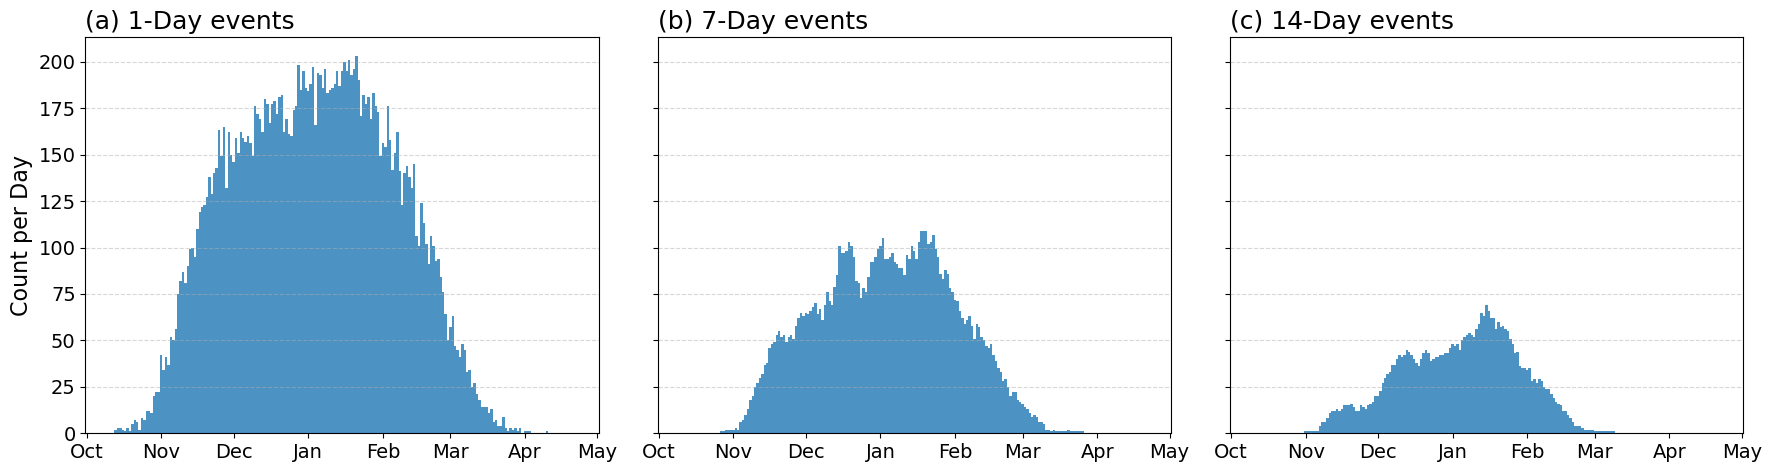

In [ ]:
# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = ['(a) 1-Day events', '(b) 7-Day events', '(c) 14-Day events']
doy_lists = [LEE_vl_dl, LEE_7_dl, LEE_14_dl]  # keep these as your DOY lists (1..365)

for ax, title, doy in zip(axes, titles, doy_lists):
    plot_oct_apr_centered(doy, title, ax=ax, left_axis=(ax is axes[0]))

plt.tight_layout()
# Save the plot
# plt.savefig('/home/onennecke/Code/Figures/LEE_Event_yearly_distr.png', bbox_inches='tight', dpi=300)
plt.show()


In [18]:
np.unique(doy)
shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]
len(np.unique(shifted))

129

In [19]:
def oct_apr_centered(doy):
    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    return counts_full

In [20]:
LEE_vl_count = oct_apr_centered(LEE_vl_dl)
LEE_7_count = oct_apr_centered(LEE_7_dl)
LEE_14_count = oct_apr_centered(LEE_14_dl)


In [21]:
print([((int(274) - 1) + 182) % 365 + 1])
print([((int(121) - 1) + 182) % 365 + 1])
print([((int(203) - 1) + 182) % 365 + 1])
print([((int(20) - 1) + 182) % 365 + 1])

[91]
[303]
[20]
[202]


In [22]:
LEE_7_count

91     0
92     0
93     0
94     0
95     0
      ..
299    0
300    0
301    0
302    0
303    0
Name: count, Length: 213, dtype: int64

In [23]:
np.sort(LEE_vl_count)
lst = LEE_vl_count.nlargest(5).index.tolist()
for i in lst:
    print(i, ': ',[((int(i) - 1) + 182) % 365 + 1])

203 :  [20]
200 :  [17]
198 :  [15]
179 :  [361]
185 :  [2]


In [24]:
LEE_vl_count[40:60]
max(LEE_vl_count)
LEE_vl_count.idxmax()
LEE_vl_count[203]
LEE_vl_count[100:115]
# LEE_vl_count


191    183
192    185
193    186
194    188
195    195
196    187
197    195
198    200
199    195
200    201
201    193
202    196
203    203
204    190
205    171
Name: count, dtype: int64

In [25]:
LEE_vl_count.idxmax()
print([((int(LEE_vl_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_7_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_14_count.idxmax()) - 1) + 182) % 365 + 1])

[20]
[17]
[14]


In [26]:
LEE_14_count

91     0
92     0
93     0
94     0
95     0
      ..
299    0
300    0
301    0
302    0
303    0
Name: count, Length: 213, dtype: int64

In [27]:
LEE_14_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_14_dl]
LEE_7_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_7_dl]
LEE_dat_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_dat_dl]


In [28]:
print(np.mean(LEE_14_dl_shifted))
print(np.median(LEE_14_dl_shifted))

185.97470817120623
188.5


In [29]:
'''from scipy import stats
import statsmodels.api as sm

# suppose `counts` is the array of daily counts for the 1-day events
# e.g. counts = np.array([...])
counts = np.array(tst)
# 1) Q-Q plot
sm.qqplot(counts, line='s')
plt.title('Q-Q plot against normal')
plt.show()

# 2) Normality tests
w, p_shapiro = stats.shapiro(counts)           # Shapiro-Wilk
k2, p_dagostino = stats.normaltest(counts)    # D'Agostino
ad_result = stats.anderson(counts, dist='norm')  # Anderson-Darling

print('Shapiro p=', p_shapiro)
print('D\'Agostino p=', p_dagostino)
print('Anderson statistic=', ad_result.statistic, 'critical=', ad_result.critical_values)'''


"from scipy import stats\nimport statsmodels.api as sm\n\n# suppose `counts` is the array of daily counts for the 1-day events\n# e.g. counts = np.array([...])\ncounts = np.array(tst)\n# 1) Q-Q plot\nsm.qqplot(counts, line='s')\nplt.title('Q-Q plot against normal')\nplt.show()\n\n# 2) Normality tests\nw, p_shapiro = stats.shapiro(counts)           # Shapiro-Wilk\nk2, p_dagostino = stats.normaltest(counts)    # D'Agostino\nad_result = stats.anderson(counts, dist='norm')  # Anderson-Darling\n\nprint('Shapiro p=', p_shapiro)\nprint('D'Agostino p=', p_dagostino)\nprint('Anderson statistic=', ad_result.statistic, 'critical=', ad_result.critical_values)"

In [30]:
'''data = np.array(LEE_14_dl_shifted)

# sample skewness (bias-corrected)
skew_corrected = stats.skew(data, bias=False)

# raw (uncorrected) moment skewness
skew_raw = stats.skew(data, bias=True)

print("skew (bias-corrected) =", skew_corrected)
print("skew (raw) =", skew_raw)'''

'data = np.array(LEE_14_dl_shifted)\n\n# sample skewness (bias-corrected)\nskew_corrected = stats.skew(data, bias=False)\n\n# raw (uncorrected) moment skewness\nskew_raw = stats.skew(data, bias=True)\n\nprint("skew (bias-corrected) =", skew_corrected)\nprint("skew (raw) =", skew_raw)'

### Check how the LEE Days are distributed over the modells

In [31]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_vl_dur_avg_ranking'] = LEE_all_comp['LEE_vl_dur_avg'].rank(ascending=False)
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg', 'LEE_vl_dur_avg_ranking']]


# LEE_dat_temp = LEE_dat.copy()
# LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
# LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
# LEE_dat_temp
# Join the two DataFrames on 'ESM'
# LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
# LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_7_dur_avg_ranking'] = LEE_all_comp['LEE_7_dur_avg'].rank(ascending=False)

LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_14_dur_avg_ranking'] = LEE_all_comp['LEE_14_dur_avg'].rank(ascending=False)

LEE_all_comp['ESM_label'] = LEE_all_comp['ESM'] + ' \n (n = ' + LEE_all_comp['Nr_of_runs'].astype(str) + ')'
# Fix the label for ERA5_week to display as "ERA5 \n (n = 1)"
LEE_all_comp.loc[LEE_all_comp['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5 \n (n = 1)'
LEE_all_comp

,ESM,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_avg,LEE_vl_dur_avg_ranking,LEE_7_dur_sum,LEE_7_dur_avg,LEE_7_dur_avg_ranking,LEE_14_dur_sum,LEE_14_dur_avg,LEE_14_dur_avg_ranking,ESM_label
0,ACCESS-CM2,3,641,213.666667,4.0,280,93.333333,4.0,112.0,37.333333,4.0,ACCESS-CM2 \n (n = 3)
1,BCC-CSM2-MR,1,229,229.000000,3.0,119,119.000000,2.0,84.0,84.000000,1.0,BCC-CSM2-MR \n (n = 1)
2,CESM2,3,298,99.333333,11.0,154,51.333333,9.0,28.0,9.333333,10.0,CESM2 \n (n = 3)
3,EC-Earth3,53,8328,157.132075,7.0,3297,62.207547,8.0,1204.0,22.716981,7.0,EC-Earth3 \n (n = 53)
4,ERA5_week,1,183,183.000000,5.0,70,70.000000,5.5,28.0,28.000000,6.0,ERA5 \n (n = 1)
5,GFDL-ESM4,1,165,165.000000,6.0,70,70.000000,5.5,NaN,NaN,NaN,GFDL-ESM4 \n (n = 1)
6,KACE-1-0-G,3,330,110.000000,10.0,147,49.000000,10.0,56.0,18.666667,8.0,KACE-1-0-G \n (n = 3)
7,MPI-ESM1-2-HR,10,2431,243.100000,2.0,1078,107.800000,3.0,602.0,60.200000,3.0,MPI-ESM1-2-HR \n (n = 10)
8,MRI-ESM2-0,5,715,143.000000,8.0,315,63.000000,7.0,154.0,30.800000,5.0,MRI-ESM2-0 \n (n = 5)
9,TaiESM1,1,141,141.000000,9.0,42,42.000000,11.0,14.0,14.000000,9.0,TaiESM1 \n (n = 1)


In [32]:
252.105263 / 99 * 100
124.157895 / 49 * 100
84.000000 / 9.3 *100

903.2258064516128

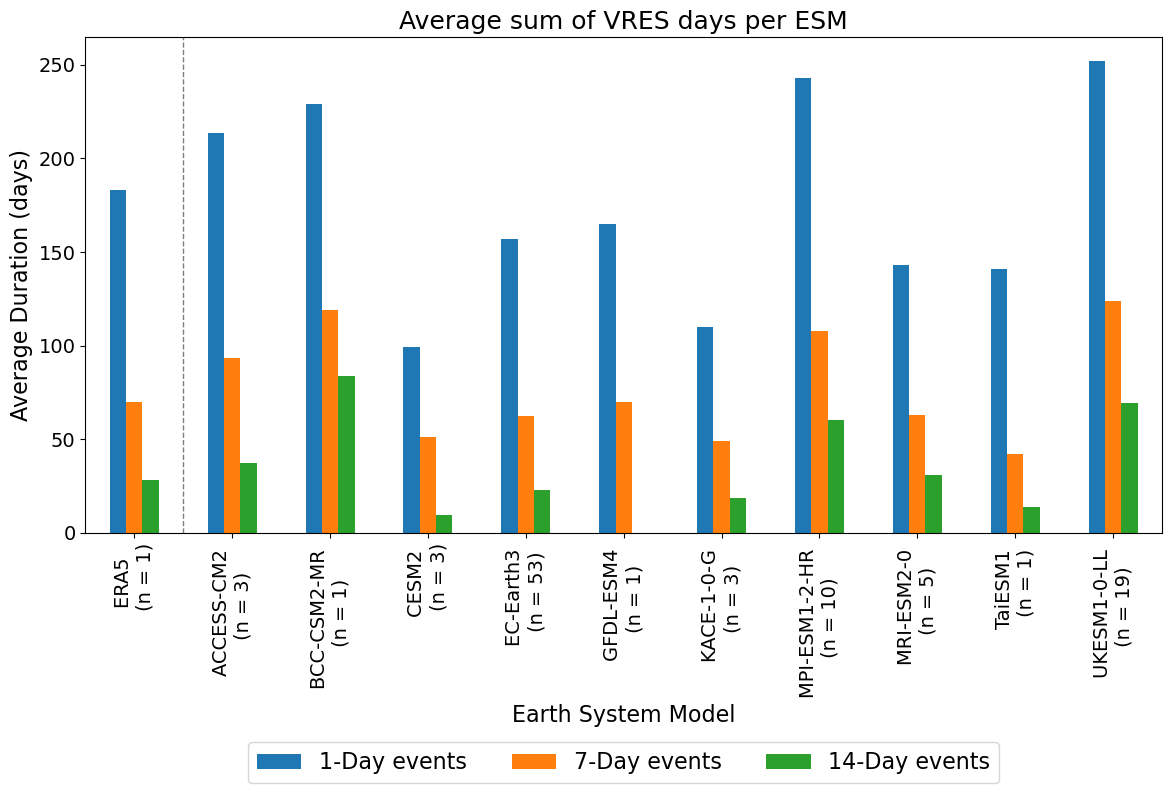

In [33]:
# make text a bit larger globally (adjust values as you like)
# plt.rcParams.update({
#     'font.size': 14,            # base font size
#     'axes.titlesize': 16,       # title
#     'axes.labelsize': 14,       # x/y labels
#     'xtick.labelsize': 13,      # x tick labels
#     'ytick.labelsize': 13,      # y tick labels
#     'legend.fontsize': 13       # legend text
# })

mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# pick the 3 columns we want
df = LEE_all_comp.set_index('ESM_label')[['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']].copy()

# find ERA5 label (works if label contains extra text like "ERA5\n(n = 1)")
era_label = next((lab for lab in df.index if 'ERA5' in lab), None)

# reorder so ERA5 is first, then the rest (no blank rows)
new_index = [era_label] + [lab for lab in df.index if lab != era_label]
df_reordered = df.loc[new_index]

# plot grouped bars
ax = df_reordered.plot(kind='bar', figsize=(12, 9))

# draw a dashed vertical line between ERA5 and the rest
era_pos = new_index.index(era_label)  # should be 0, but computed generally
# place line halfway between ERA5 group and the next group
x_line = era_pos + 0.5
ax.axvline(x=x_line, color="#7E7E7E", linestyle='--', linewidth=1, label='_nolegend_')

# cosmetics
legend = ['1-Day events', '7-Day events', '14-Day events']
ax.set_title('Average sum of VRES days per ESM')
ax.legend(legend, loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
ax.set_ylabel('Average Duration (days)')
ax.set_xlabel('Earth System Model')
ax.set_xticklabels(df_reordered.index, rotation=90)
plt.tight_layout()

# plt.savefig('/home/onennecke/Code/Figures/LEE_durations_comparison.png', dpi=300)

plt.show()


# VL Events analysis

In [34]:
LEE_vl['duration'].max()

np.int64(23)

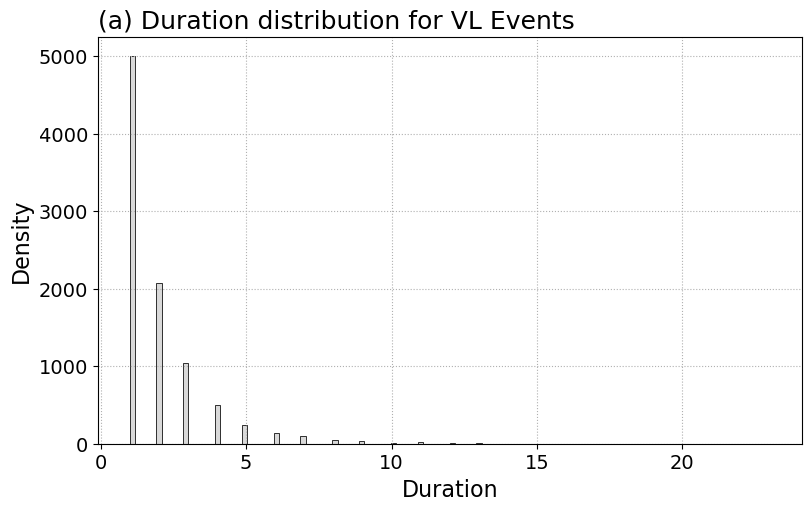

In [35]:
# --- changed code: single smoothed histogram for LEE_vl['duration'] ---
# --- changed code: single standard histogram for LEE_vl['duration'] ---

bins = 120
figsize = (8,5)
color_fill = '#d9d9d9'
edge_color = '#111111'
fill_alpha = 1
lw_edge = 0.6

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# extract duration array
dur = np.asarray(LEE_vl['duration']).ravel()

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# standard histogram (density=True -> area sums to 1)
ax.hist(dur, bins=bins, density=False, log=False,
        color=color_fill, alpha=fill_alpha,
        edgecolor=edge_color, linewidth=lw_edge)

ax.set_xlabel('Duration')
ax.set_ylabel('Density')
ax.set_title("(a) Duration distribution for VL Events", loc='left')
ax.grid(True, linestyle=':', alpha=1)

# plt.savefig('/home/onennecke/Code/Figures/VL_LEE_duration_histogram.png', bbox_inches='tight', dpi=300)
plt.show()


In [37]:
LEE_vl.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,Nr_of_runs
7481,2023-11-18,2023-12-10,2023-11-18 00:00:00.000000014,3241,3263,3255,23,1518.845215,1455.361885,33.685570,33473.323366,7482,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2023,322,19
6581,2017-01-02,2017-01-21,2017-01-02 00:00:00.000000018,731,750,749,20,1519.938828,1473.785364,31.958385,29475.707282,6582,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r8i1p1f1,2017,2,10
7395,2017-01-01,2017-01-19,2017-01-01 00:00:00.000000003,730,748,733,19,1650.189929,1535.789631,70.122670,29180.002998,7396,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2017,1,19
6168,2020-11-29,2020-12-15,2020-11-29 00:00:00.000000008,2157,2173,2165,17,1564.573329,1513.522835,43.637916,25729.888203,6169,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r4i1p1f1,2020,333,10
7903,2019-12-28,2020-01-11,2019-12-28 00:00:00.000000005,1821,1835,1826,15,1642.508641,1564.576632,69.816188,23468.649479,7904,UKESM1-0-LL,UKESM1-0-LL_r15i1p1f2,2019,362,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9366,2024-01-21,2024-01-21,2024-01-21 00:00:00.000000000,3305,3305,3305,1,1416.096851,1416.096851,0.000000,1416.096851,9367,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,21,19
9365,2024-01-07,2024-01-07,2024-01-07 00:00:00.000000000,3291,3291,3291,1,1449.493442,1449.493442,0.000000,1449.493442,9366,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,7,19
9364,2024-01-01,2024-01-01,2024-01-01 00:00:00.000000000,3285,3285,3285,1,1429.298227,1429.298227,0.000000,1429.298227,9365,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,1,19
9363,2023-12-30,2023-12-30,2023-12-30 00:00:00.000000000,3283,3283,3283,1,1421.535351,1421.535351,0.000000,1421.535351,9364,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,364,19


# Return Time plot

In [37]:
LEE_dat['RL_cumulative']
LEE_dat_ERA5['RL_cumulative']
LEE_7['RL_cumulative']
LEE_7_ERA5['RL_cumulative']
LEE_14['RL_cumulative']
LEE_14_ERA5['RL_cumulative']

102    19873.386652
103    19897.361326
Name: RL_cumulative, dtype: float64

In [38]:
LEE_14_ERA5['RL_cumulative']

102    19873.386652
103    19897.361326
Name: RL_cumulative, dtype: float64

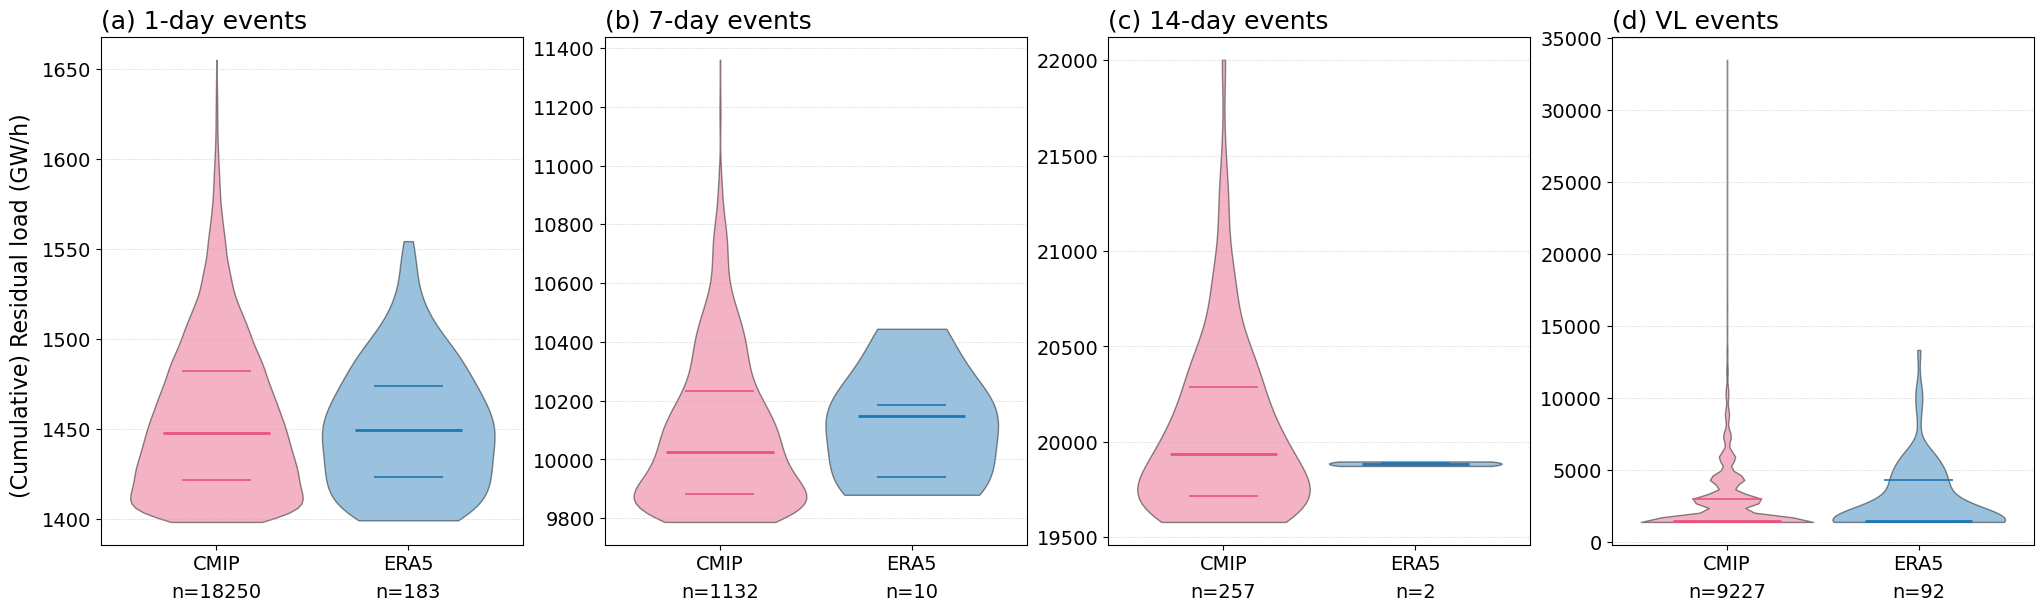

In [46]:
# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

def plot_violin(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    cmip_vl, era_vl,
    outpath=None,
    colors=None,
    figsize=(20, 6),
    title_suffix="",
):
    """
    Create a 4-panel figure with paired violins (CMIP vs ERA5) for
    1-day, 7-day, 14-day and 'vl' events.

    Parameters
    ----------
    cmip_1, era_1, cmip_7, era_7, cmip_14, era_14, cmip_vl, era_vl : array-like
        1D arrays or pandas Series containing the 'RL_cumulative' values
        for CMIP and ERA5 for each event duration.
    outpath : str or None
        If provided, save the figure to this path (PNG). If None, no file is saved.
    colors : list-like of two color strings
        [cmip_color, era_color]. Default: ['#e75480', '#1f77b4'] (pink, blue).
    figsize : tuple
        Figure size passed to plt.subplots.
    title_suffix : str
        Optional string appended to each subplot title.

    Returns
    -------
    fig, axes
        The matplotlib figure and axes for further customization.
    """

    colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue

    datasets = [
        (cmip_1, era_1),
        (cmip_7, era_7),
        (cmip_14, era_14),
        (cmip_vl, era_vl),
    ]
    titles = [
        f"(a) 1-day events {title_suffix}".strip(),
        f"(b) 7-day events {title_suffix}".strip(),
        f"(c) 14-day events {title_suffix}".strip(),
        f"(d) VL events {title_suffix}".strip()
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False, constrained_layout=True)

    for ax, (cmip, era), title in zip(axes, datasets, titles):

        # build violinplot: positions 1 (CMIP) and 2 (ERA)
        parts = ax.violinplot(dataset=[cmip, era], positions=[1, 2], vert=True,
                              widths=0.9, showextrema=False, showmedians=False)

        # style violin bodies
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # compute summary stats
        medians = [np.median(cmip) if cmip.size else np.nan,
                   np.median(era) if era.size else np.nan]
        q1 = [np.percentile(cmip, 25) if cmip.size else np.nan,
              np.percentile(era, 25) if era.size else np.nan]
        q3 = [np.percentile(cmip, 75) if cmip.size else np.nan,
              np.percentile(era, 75) if era.size else np.nan]
        mins = [np.min(cmip) if cmip.size else np.nan,
                np.min(era) if era.size else np.nan]
        maxs = [np.max(cmip) if cmip.size else np.nan,
                np.max(era) if era.size else np.nan]

        # Draw median and quartiles and small min/max markers
        for i, pos in enumerate([1, 2]):
            # median
            if not np.isnan(medians[i]):
                ax.hlines(medians[i], pos - 0.28, pos + 0.28, color=colors[i], linewidth=2.0)
            # quartiles
            if not np.isnan(q1[i]) and not np.isnan(q3[i]):
                ax.hlines(q1[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
                ax.hlines(q3[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
            # min/max ticks (as short vertical lines)
            if not np.isnan(mins[i]):
                ax.vlines(pos - 0.08, mins[i], mins[i], color=colors[i], linewidth=2.0)
            if not np.isnan(maxs[i]):
                ax.vlines(pos + 0.08, maxs[i], maxs[i], color=colors[i], linewidth=2.0)

            # annotate sample size above each violin
            sample_n = cmip.size if i == 0 else era.size
            # place annotation just above top of axis range (we'll adjust later once y-limits set)
            ax.text(pos, -0.11, f"n={sample_n}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=14, color='black')

        # x ticks
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['CMIP', 'ERA5'], rotation=0)
        ax.set_title(title, fontsize=18, loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
        ax.set_xlim(0.4, 2.6)

    # Shared y-label on the left for clarity
    fig.text(-0.014, 0.5, '(Cumulative) Residual load (GW/h)', va='center', rotation='vertical', fontsize=16)

    # Optionally save
    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes

fig, axes = plot_violin(
    cmip_1  = LEE_dat['RL_cumulative'],
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7  = LEE_7['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14 = LEE_14['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl = LEE_vl['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    outpath='/home/onennecke/Code/Figures/LEE_RL_cumulative_violin_comparison.png',
)


# Old

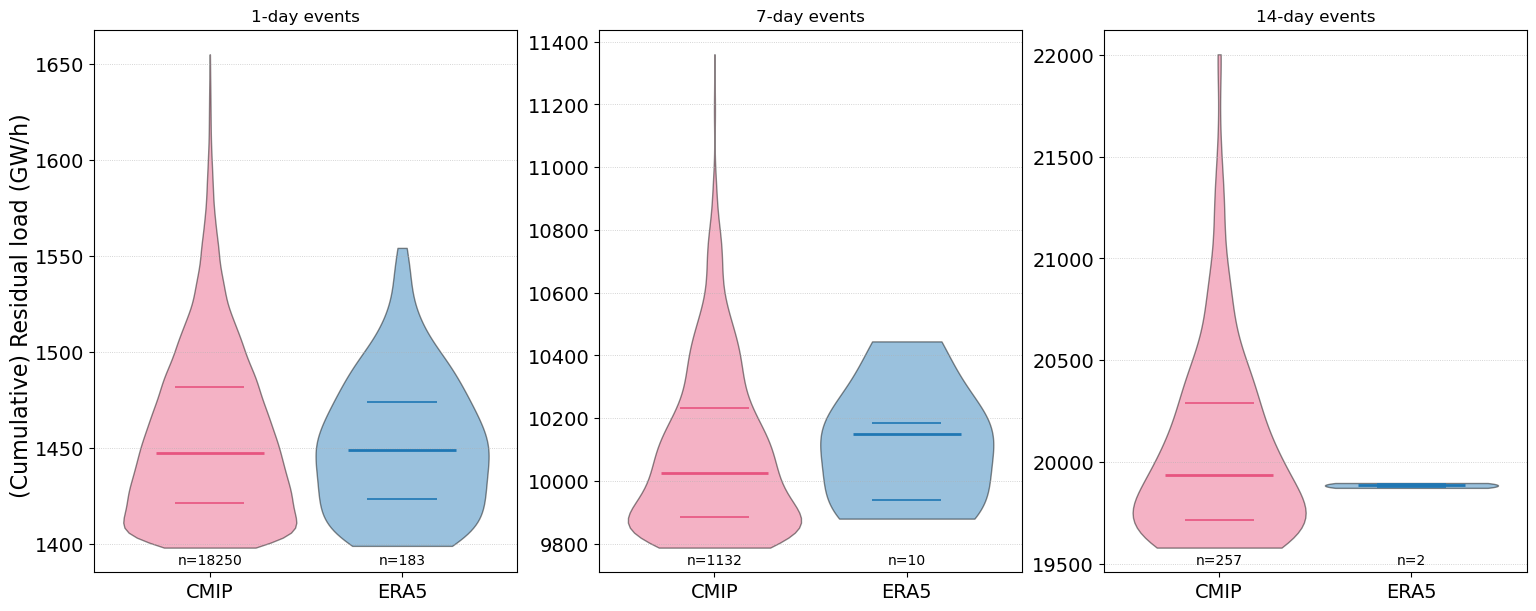

(<Figure size 1500x600 with 3 Axes>,
 array([<Axes: title={'center': '1-day events'}>,
        <Axes: title={'center': '7-day events'}>,
        <Axes: title={'center': '14-day events'}>], dtype=object))

In [41]:


def plot_violin_triplet(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    outpath=None,
    colors=None,
    figsize=(15, 6),
    title_suffix="",
):
    """
    Create a 3-panel figure with paired violins (CMIP vs ERA5) for
    1-day, 7-day and 14-day events.

    Parameters
    ----------
    cmip_1, era_1, cmip_7, era_7, cmip_14, era_14 : array-like
        1D arrays or pandas Series containing the 'RL_cumulative' values
        for CMIP and ERA5 for each event duration.
    outpath : str or None
        If provided, save the figure to this path (PNG). If None, no file is saved.
    colors : list-like of two color strings
        [cmip_color, era_color]. Default: ['#e75480', '#1f77b4'] (pink, blue).
    figsize : tuple
        Figure size passed to plt.subplots.
    title_suffix : str
        Optional string appended to each subplot title.

    Returns
    -------
    fig, axes
        The matplotlib figure and axes for further customization.
    """

    colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue

    datasets = [
        (cmip_1, era_1),
        (cmip_7, era_7),
        (cmip_14, era_14),
    ]
    titles = [f"1-day events {title_suffix}".strip(),
              f"7-day events {title_suffix}".strip(),
              f"14-day events {title_suffix}".strip()]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False, constrained_layout=True)

    for ax, (cmip, era), title in zip(axes, datasets, titles):

        # build violinplot: positions 1 (CMIP) and 2 (ERA)
        parts = ax.violinplot(dataset=[cmip, era], positions=[1, 2], vert=True,
                              widths=0.9, showextrema=False, showmedians=False)

        # style violin bodies
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # compute summary stats
        medians = [np.median(cmip) if cmip.size else np.nan,
                   np.median(era) if era.size else np.nan]
        q1 = [np.percentile(cmip, 25) if cmip.size else np.nan,
              np.percentile(era, 25) if era.size else np.nan]
        q3 = [np.percentile(cmip, 75) if cmip.size else np.nan,
              np.percentile(era, 75) if era.size else np.nan]
        mins = [np.min(cmip) if cmip.size else np.nan,
                np.min(era) if era.size else np.nan]
        maxs = [np.max(cmip) if cmip.size else np.nan,
                np.max(era) if era.size else np.nan]

        # Draw median and quartiles and small min/max markers
        for i, pos in enumerate([1, 2]):
            # median
            if not np.isnan(medians[i]):
                ax.hlines(medians[i], pos - 0.28, pos + 0.28, color=colors[i], linewidth=2.0)
            # quartiles
            if not np.isnan(q1[i]) and not np.isnan(q3[i]):
                ax.hlines(q1[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
                ax.hlines(q3[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
            # min/max ticks (as short vertical lines)
            if not np.isnan(mins[i]):
                ax.vlines(pos - 0.08, mins[i], mins[i], color=colors[i], linewidth=2.0)
            if not np.isnan(maxs[i]):
                ax.vlines(pos + 0.08, maxs[i], maxs[i], color=colors[i], linewidth=2.0)

            # annotate sample size above each violin
            sample_n = cmip.size if i == 0 else era.size
            # place annotation just above top of axis range (we'll adjust later once y-limits set)
            ax.text(pos, 0.01, f"n={sample_n}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=10, color='black')

        # x ticks
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['CMIP', 'ERA5'], rotation=0)
        ax.set_title(title, fontsize=12)
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
        ax.set_xlim(0.4, 2.6)

    # Shared y-label on the left for clarity
    fig.text(-0.014, 0.5, '(Cumulative) Residual load (GW/h)', va='center', rotation='vertical', fontsize=16)

    # # Legend in top center
    # legend_handles = [Patch(facecolor=colors[0], edgecolor='k', alpha=0.45, label='CMIP'),
    #                   Patch(facecolor=colors[1], edgecolor='k', alpha=0.45, label='ERA5')]
    # fig.legend(handles=legend_handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1))

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes

# ---------------------------
# Example usage (uncomment and replace with your actual arrays/Series):
#
plot_violin_triplet(
    cmip_1 = LEE_dat['RL_cumulative'],
    era_1  = LEE_dat_ERA5['RL_cumulative'],
    cmip_7 = LEE_7['RL_cumulative'],
    era_7  = LEE_7_ERA5['RL_cumulative'],
    cmip_14= LEE_14['RL_cumulative'],
    era_14 = LEE_14_ERA5['RL_cumulative'])
#
# ---------------------------


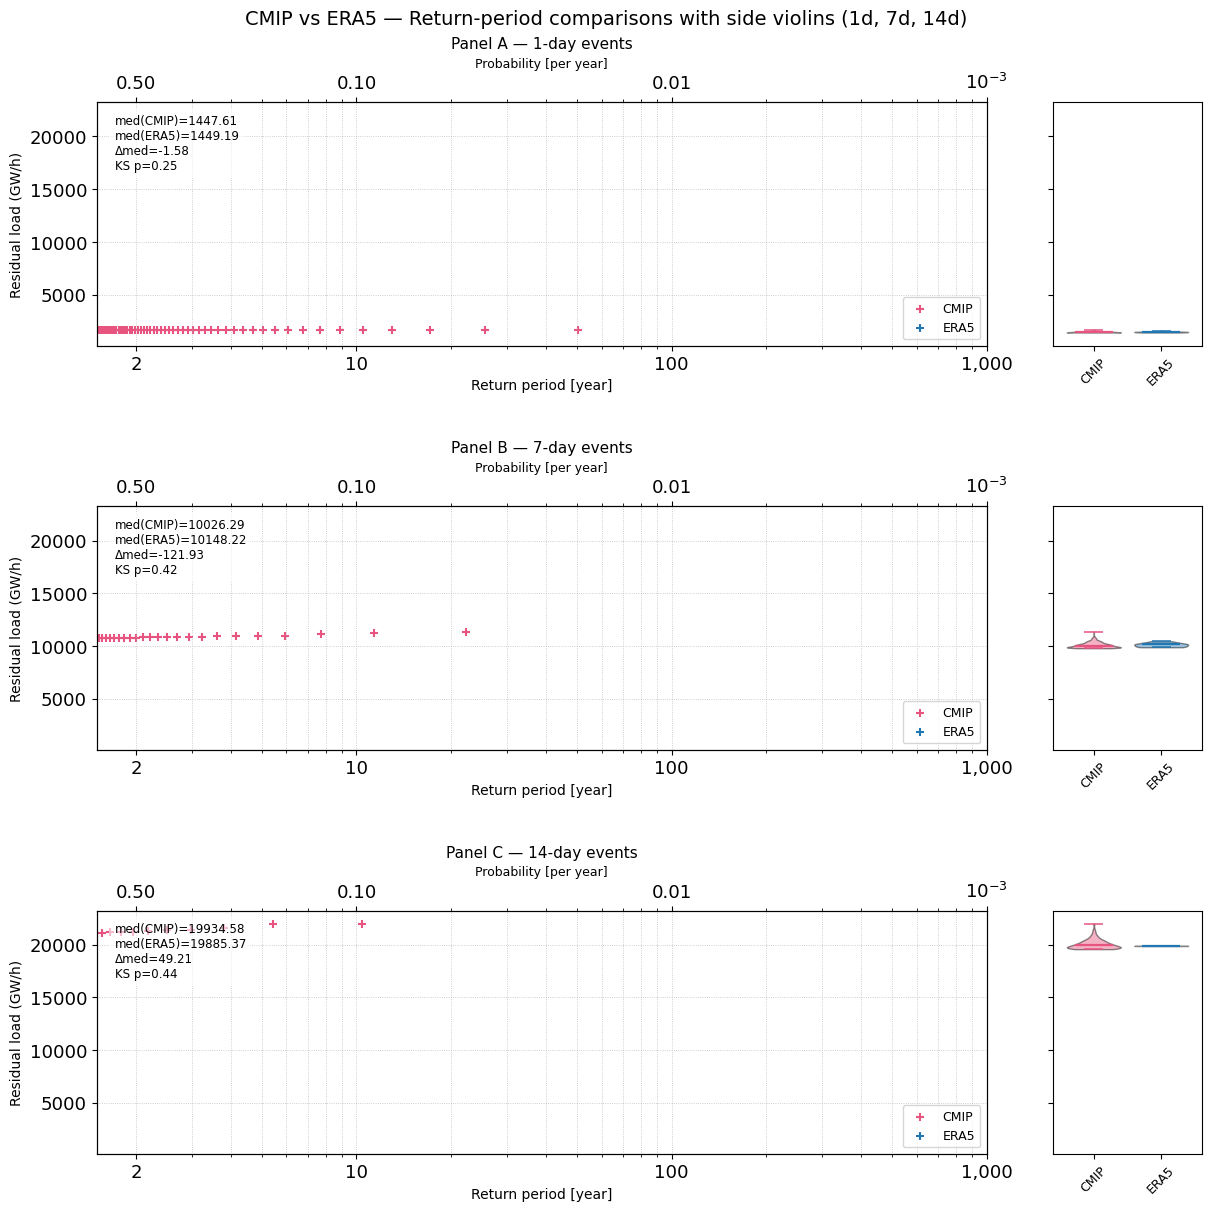

In [ ]:


# --- Inputs (your variables) ---
# 1-day
# LEE_dat['RL_cumulative']
# LEE_dat_ERA5['RL_cumulative']
# 7-day
# LEE_7['RL_cumulative']
# LEE_7_ERA5['RL_cumulative']
# 14-day
# LEE_14['RL_cumulative']
# LEE_14_ERA5['RL_cumulative']

# ---------- plotting routine ----------
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue
days_per_year = 365.0
max_rp = 1e3
min_rp = 1.0

def to_numpy_dropna(series_like):
    """Accept pandas Series or numpy array; return 1D numpy array with NaNs removed."""
    if isinstance(series_like, (pd.Series, pd.DataFrame)):
        vals = series_like.values.ravel()
    else:
        vals = np.asarray(series_like).ravel()
    vals = vals[~np.isnan(vals)]
    return vals

def empirical_exceedance(values):
    """Return sorted values and per-sample exceedance probability (period basis)."""
    vals = np.sort(values)
    n = len(vals)
    if n == 0:
        return np.array([]), np.array([])
    # plotting-friendly empirical exceedance: 1 - rank/(n+1)
    exceed_prob = 1.0 - np.arange(1, n + 1) / (n + 1)
    return vals, exceed_prob

def rp_from_period_exceedance(exceed_prob_period, duration_days):
    """Convert per-period exceedance -> per-year return period (years)."""
    if len(exceed_prob_period) == 0:
        return np.array([])
    periods_per_year = days_per_year / float(duration_days)
    # per-year exceedance prob:
    p_year = 1.0 - (1.0 - exceed_prob_period) ** periods_per_year
    # avoid division by zero
    rp = np.where(p_year > 0, 1.0 / p_year, np.inf)
    return rp

def plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days, title_label):
    # convert to numpy
    cmip = to_numpy_dropna(cmip_arr)
    era  = to_numpy_dropna(era_arr)

    # empirical survival / exceedance (period basis)
    era_vals, era_p_period = empirical_exceedance(era)
    cmip_vals, cmip_p_period = empirical_exceedance(cmip)

    # convert to return periods (years) for plotting on x-axis
    era_rp = rp_from_period_exceedance(era_p_period, duration_days)
    cmip_rp = rp_from_period_exceedance(cmip_p_period, duration_days)

    # masks for readability: keep only rp within [min_rp, max_rp]
    era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
    cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)

    era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
    cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

    # scatter points (main axis)
    ax_main.scatter(cmip_rp_plot, cmip_vals_plot, marker='+', s=28, color=colors[0], label='CMIP')
    ax_main.scatter(era_rp_plot, era_vals_plot, marker='+', s=28, color=colors[1], label='ERA5')

    ax_main.set_xscale('log')
    ax_main.set_xlim(1.5, max_rp)
    ax_main.set_xlabel('Return period [year]', fontsize=10)
    ax_main.set_ylabel('Residual load (GW/h)', fontsize=10)
    ax_main.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

    # xticks and top probability axis
    bottom_ticks = [2, 10, 100, 1000]
    ax_main.set_xticks(bottom_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    top = ax_main.twiny()
    top.set_xscale('log')
    top.set_xlim(ax_main.get_xlim())
    top.set_xticks(bottom_ticks)
    # probability per year = 1/RP
    top_labels = [f'{1.0/rp:.0e}' for rp in bottom_ticks]
    # nicer: show as 10^{-k} where applicable
    top_labels_pretty = []
    for rp in bottom_ticks:
        prob = 1.0 / rp
        if prob < 1e-2:
            # show scientific style 10^{-k}
            k = int(np.round(-np.log10(prob)))
            top_labels_pretty.append(r'$10^{-%d}$' % k)
        else:
            top_labels_pretty.append(f'{prob:.2f}')
    top.set_xticklabels(top_labels_pretty)
    top.set_xlabel('Probability [per year]', fontsize=9)

    # legend + title
    ax_main.legend(loc='lower right', fontsize=9)
    ax_main.set_title(f'{title_label} — {duration_days}-day events', fontsize=11)

    # violin on right (narrow)
    data_for_violin = [cmip, era]
    positions = [1.0, 2.0]
    parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                                 widths=0.8, showextrema=False, showmedians=False)

    # draw medians & min/max
    medians = [np.median(cmip) if cmip.size else np.nan, np.median(era) if era.size else np.nan]
    maxes   = [np.max(cmip) if cmip.size else np.nan,     np.max(era) if era.size else np.nan]
    mins    = [np.min(cmip) if cmip.size else np.nan,     np.min(era) if era.size else np.nan]

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.45)
        # median line
        ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.6)
        # min/max short lines
        ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)
        ax_violin.hlines(mins[i],  positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)

    ax_violin.set_xticks(positions)
    ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45, fontsize=9)
    ax_violin.yaxis.set_tick_params(labelleft=False)  # hide duplicate y tick labels
    ax_violin.set_xlim(0.4, 2.6)
    ax_violin.set_ylim(ax_main.get_ylim())

    # annotate simple stats (median difference, KS p-value)
    try:
        ks_stat, ks_p = stats.ks_2samp(cmip, era, alternative='two-sided', mode='asymp')
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    med_diff = medians[0] - medians[1]
    txt = f'med(CMIP)={medians[0]:.2f}\nmed(ERA5)={medians[1]:.2f}\nΔmed={med_diff:.2f}\nKS p={ks_p:.2g}'
    ax_main.text(0.02, 0.95, txt, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# ---------- assemble figure ----------
def make_three_rp_violins(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    figsize=(12, 12)
):
    # compute a global y-limits across all arrays for consistent comparison
    all_vals = np.concatenate([
        to_numpy_dropna(cmip_1), to_numpy_dropna(era_1),
        to_numpy_dropna(cmip_7), to_numpy_dropna(era_7),
        to_numpy_dropna(cmip_14), to_numpy_dropna(era_14)
    ])
    if all_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
        pad = 0.06 * (vmax - vmin if vmax > vmin else max(1.0, abs(vmax)))
        vmin -= pad
        vmax += pad

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    # 3 rows x 2 cols (left=main, right=violin), use GridSpec
    gs = fig.add_gridspec(3, 2, width_ratios=[6, 1], hspace=0.12, wspace=0.06)

    datasets = [
        (cmip_1, era_1, 1, 'Panel A'),
        (cmip_7, era_7, 7, 'Panel B'),
        (cmip_14, era_14, 14, 'Panel C'),
    ]

    for row, (cmip_arr, era_arr, days, label) in enumerate(datasets):
        ax_main = fig.add_subplot(gs[row, 0])
        ax_violin = fig.add_subplot(gs[row, 1], sharey=ax_main)
        # set same ylims for each subplot
        ax_main.set_ylim(vmin, vmax)
        plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days=days, title_label=label)

    # overall title
    fig.suptitle('CMIP vs ERA5 — Return-period comparisons with side violins (1d, 7d, 14d)', fontsize=14)
    plt.show()
    return fig

# ---------- Example call using your objects ----------
# Uncomment and run (replace the variable names with your actual objects if different)
fig = make_three_rp_violins(
    LEE_dat['RL_cumulative'], LEE_dat_ERA5['RL_cumulative'],
    LEE_7['RL_cumulative'], LEE_7_ERA5['RL_cumulative'],
    LEE_14['RL_cumulative'], LEE_14_ERA5['RL_cumulative'],
)
fig.savefig('CMIP_ERA5_RP_violins_1_7_14d.png', dpi=300, bbox_inches='tight')


/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)


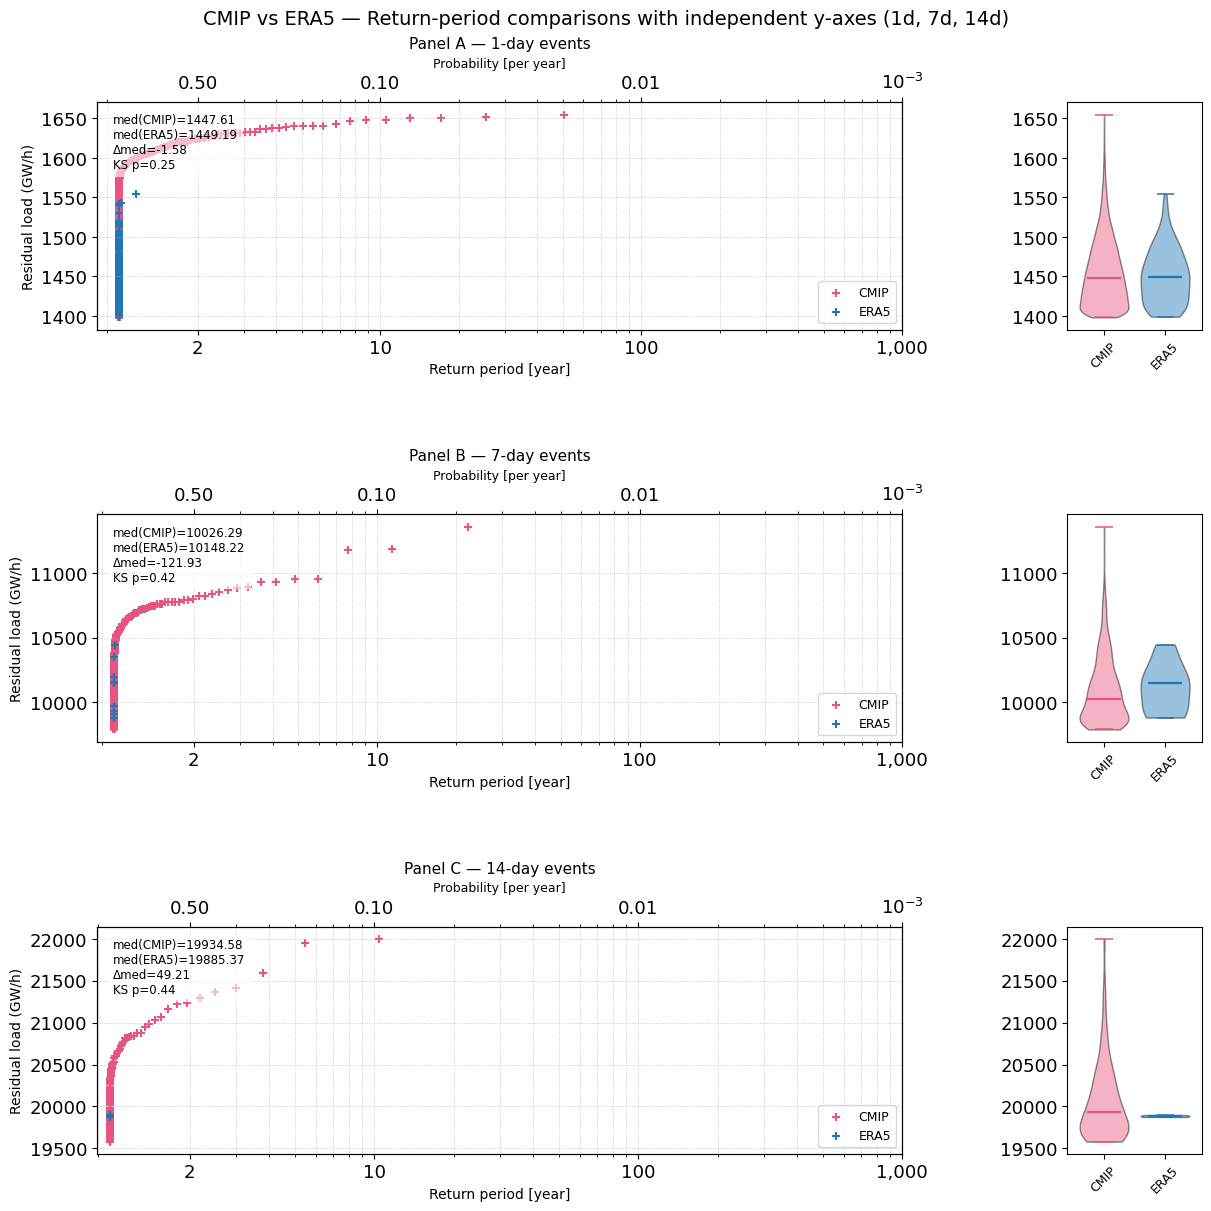

In [ ]:

# ---------- helper functions ----------
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue
days_per_year = 365.0
max_rp = 1e3
min_rp = 1.0

def to_numpy_dropna(series_like):
    if isinstance(series_like, (pd.Series, pd.DataFrame)):
        vals = series_like.values.ravel()
    else:
        vals = np.asarray(series_like).ravel()
    vals = vals[~np.isnan(vals)]
    return vals

def empirical_exceedance(values):
    vals = np.sort(values)
    n = len(vals)
    if n == 0:
        return np.array([]), np.array([])
    exceed_prob = 1.0 - np.arange(1, n + 1) / (n + 1)
    return vals, exceed_prob

def rp_from_period_exceedance(exceed_prob_period, duration_days):
    if len(exceed_prob_period) == 0:
        return np.array([])
    periods_per_year = days_per_year / float(duration_days)
    p_year = 1.0 - (1.0 - exceed_prob_period) ** periods_per_year
    rp = np.where(p_year > 0, 1.0 / p_year, np.inf)
    return rp

def plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days, title_label):
    cmip = to_numpy_dropna(cmip_arr)
    era  = to_numpy_dropna(era_arr)

    era_vals, era_p_period = empirical_exceedance(era)
    cmip_vals, cmip_p_period = empirical_exceedance(cmip)

    era_rp = rp_from_period_exceedance(era_p_period, duration_days)
    cmip_rp = rp_from_period_exceedance(cmip_p_period, duration_days)

    era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
    cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)

    era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
    cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

    # scatter points
    ax_main.scatter(cmip_rp_plot, cmip_vals_plot, marker='+', s=28, color=colors[0], label='CMIP')
    ax_main.scatter(era_rp_plot, era_vals_plot, marker='+', s=28, color=colors[1], label='ERA5')

    ax_main.set_xscale('log')
    ax_main.set_xlim(0, max_rp)
    ax_main.set_xlabel('Return period [year]', fontsize=10)
    ax_main.set_ylabel('Residual load (GW/h)', fontsize=10)
    ax_main.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

    bottom_ticks = [2, 10, 100, 1000]
    ax_main.set_xticks(bottom_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    top = ax_main.twiny()
    top.set_xscale('log')
    top.set_xlim(ax_main.get_xlim())
    top.set_xticks(bottom_ticks)
    # nicer labels for top axis
    top_labels_pretty = []
    for rp in bottom_ticks:
        prob = 1.0 / rp
        if prob < 1e-2:
            k = int(np.round(-np.log10(prob)))
            top_labels_pretty.append(r'$10^{-%d}$' % k)
        else:
            top_labels_pretty.append(f'{prob:.2f}')
    top.set_xticklabels(top_labels_pretty)
    top.set_xlabel('Probability [per year]', fontsize=9)

    ax_main.legend(loc='lower right', fontsize=9)
    ax_main.set_title(f'{title_label} — {duration_days}-day events', fontsize=11)

    # --- set y-limits PER ROW (so each row has own y-axis) ---
    # compute y-limits from the two arrays for this row
    combined = np.concatenate([cmip, era]) if (cmip.size + era.size) > 0 else np.array([0.0])
    vmin = np.nanmin(combined)
    vmax = np.nanmax(combined)
    if vmin == vmax:
        # small fudge to avoid zero-range
        vmin -= 0.5 * abs(vmin) + 0.5
        vmax += 0.5 * abs(vmax) + 0.5
    pad = 0.06 * (vmax - vmin)
    ax_main.set_ylim(vmin - pad, vmax + pad)

    # violin (do NOT share y with other rows)
    data_for_violin = [cmip, era]
    positions = [1.0, 2.0]
    parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                                 widths=0.8, showextrema=False, showmedians=False)

    medians = [np.median(cmip) if cmip.size else np.nan, np.median(era) if era.size else np.nan]
    maxes   = [np.max(cmip) if cmip.size else np.nan,     np.max(era) if era.size else np.nan]
    mins    = [np.min(cmip) if cmip.size else np.nan,     np.min(era) if era.size else np.nan]

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.45)
        ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.6)
        ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)
        ax_violin.hlines(mins[i],  positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)

    ax_violin.set_xticks(positions)
    ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45, fontsize=9)
    # do NOT hide violin y ticks now — each row has its own y-axis so keep them visible for readability
    ax_violin.set_xlim(0.4, 2.6)
    # set violin y-limits to match the main axis for the same row so the shapes align vertically
    ax_violin.set_ylim(ax_main.get_ylim())

    # annotate statistics
    try:
        ks_stat, ks_p = stats.ks_2samp(cmip, era, alternative='two-sided', mode='asymp')
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    med_diff = medians[0] - medians[1]
    txt = f'med(CMIP)={medians[0]:.2f}\nmed(ERA5)={medians[1]:.2f}\nΔmed={med_diff:.2f}\nKS p={ks_p:.2g}'
    ax_main.text(0.02, 0.95, txt, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# ---------- assemble figure with independent y-axes per row ----------
def make_three_rp_violins_independent_y(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    figsize=(12, 12)
):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(3, 2, width_ratios=[6, 1], hspace=0.18, wspace=0.12)

    datasets = [
        (cmip_1, era_1, 1, 'Panel A'),
        (cmip_7, era_7, 7, 'Panel B'),
        (cmip_14, era_14, 14, 'Panel C'),
    ]

    for row, (cmip_arr, era_arr, days, label) in enumerate(datasets):
        ax_main = fig.add_subplot(gs[row, 0])
        ax_violin = fig.add_subplot(gs[row, 1])  # no sharey
        plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days=days, title_label=label)

    fig.suptitle('CMIP vs ERA5 — Return-period comparisons with independent y-axes (1d, 7d, 14d)', fontsize=14)
    plt.show()
    return fig

# ---------- Example call (uncomment to run) ----------
fig = make_three_rp_violins_independent_y(
    LEE_dat['RL_cumulative'], LEE_dat_ERA5['RL_cumulative'],
    LEE_7['RL_cumulative'], LEE_7_ERA5['RL_cumulative'],
    LEE_14['RL_cumulative'], LEE_14_ERA5['RL_cumulative'],
)
# fig.savefig('CMIP_ERA5_RP_violins_1_7_14d_indepY.png', dpi=300, bbox_inches='tight')


----

## Calculation of SRLI (OLD)

In [ ]:


def compute_srli(data_array, eps=1e-4): #1/(2*180180)
    """
    Compute the SRLI (Standardised Residual Load Index) over the full dataset,
    while keeping the shape and metadata of the input xarray DataArray.

    Parameters:
    - data_array (xarray.DataArray): input residual load (shape: ESM_run x time)

    Returns:
    - srli (xarray.DataArray): same shape as input, with SRLI values
    """
    # Compute ECDF ranks using Dask
    def ecdf_rank(values):
        # Sort the values
        sorted_vals = np.sort(values)
        # Use searchsorted to get the ECDF
        ranks = np.searchsorted(sorted_vals, values, side="right")
        ecdf_vals = (ranks + 1) / (len(values) + 1)
        return np.clip(ecdf_vals, eps, 1 - eps)  # avoid 0 and 1
    
    
    # Compute ECDF on full dataset (across all dimensions)
    ecdf = data_array.copy(data=da.map_blocks(
        lambda block: ecdf_rank(block.flatten()).reshape(block.shape),
        data_array.data,
        dtype=float
    ))

    # Apply inverse normal CDF (probit function)
    srli = xr.apply_ufunc(
        norm.ppf,
        ecdf,
        dask='parallelized',
        output_dtypes=[float]
    )

    # Rename the result
    srli.name = "SRLI"

    return srli


In [89]:
srli_tst = compute_srli(RL)

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool = xr.where(srli_tst.values > 1.64, True, False)

# Find contiguous regions of exceed_bool = True
events, n_events = ndimage.label(exceed_bool)

In [74]:
events

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

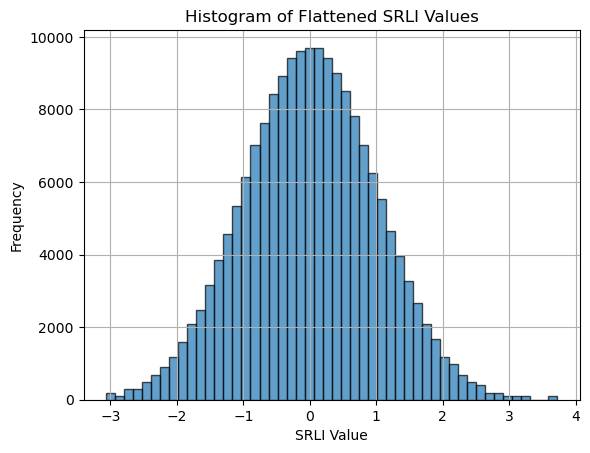

In [ ]:

# Flatten the SRLI values and create a histogram
plt.hist(srli_tst.values.flatten(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('SRLI Value')
plt.ylabel('Frequency')
plt.title('Histogram of Flattened SRLI Values')
plt.grid(True)
plt.show()

## Old Code

#### SRLI for individual run

In [ ]:


def calculate_srli(residual_load_series):
    """
    Calculate the Standardised Residual Load Index (SRLI) from a series of residual load values.
    
    Parameters:
    - residual_load_series: pd.Series or np.array of residual load values

    Returns:
    - srli_values: np.array of SRLI values
    """
    # Ensure data is a numpy array
    data = np.array(residual_load_series)
    
    # Rank the data to calculate the empirical CDF
    sorted_data = np.sort(data)
    ranks = np.searchsorted(sorted_data, data, side='right')
    empirical_cdf = (ranks + 1) / (len(data) + 1)

    # Apply the inverse of the standard normal CDF (probit)
    srli_values = norm.ppf(empirical_cdf)
    
    return srli_values